# Análisis de Métricas de Simplificación de Texto
Este notebook analiza los resultados de la simplificación de texto por diferentes herramientas y modelos, utilizando las métricas SARI, BLEU, BERTScore y los Índices de Legibilidad (Fernández Huerta, Inflesz y Mu).

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.metrics.process_data import SummaryColumn 
from src.metrics.mer_trans_metrics.calculator import MerTrans
from src.utils import clean_text

In [19]:
# Configuración de estilos para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar los datos
df = pd.read_excel('metrics.xlsx', sheet_name='Summary by Document')

# Limpiar los datos: quitar PROMEDIO
df = df[df['document_id'] != 'PROMEDIO'].copy()

# Definir grupos: Normas UNE vs Modelos
une_tools = ['FACILE', 
'SimpleText (ClearText)']
df['Grupo'] = df['document_id'].apply(lambda x: 'Normas UNE' if x in une_tools else 'Modelos IA')

# Seleccionar las métricas clave para el análisis
metricas = [
    SummaryColumn.ORIG_BLEU,
    SummaryColumn.GOLD_BLEU,
    SummaryColumn.ORIG_SARI,
    SummaryColumn.ORIG_BERTSCORE_F1,
    SummaryColumn.GOLD_BERTSCORE_F1,
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.GOLD_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING,
    SummaryColumn.GOLD_ROBERTA_SENSE_FACIL_PRESERVES_MEANING,
    "Cumplimiento"
    ]

print("Datos cargados correctamente. Total de herramientas a analizar:", len(df))


Datos cargados correctamente. Total de herramientas a analizar: 11


In [20]:
DATA_TOTAL_CHECKER = "totales_checkers.xlsx"
df_total_checker = pd.read_excel(DATA_TOTAL_CHECKER)
df_total_checker.rename(columns={"Unnamed: 0": "Tool"}, inplace=True)
df_total_checker

,Tool,Items Cumplidos,Cumplimiento
0,FACILE,4.5,75.000
1,Placea,4.5,75.000
2,Asistente de lectura fácil “ANTONIO GONZALES C...,4.5,75.000
3,Gemini 3.1 Pro,4.5,75.000
4,GPT 5.4 Think,4.5,75.000
5,Claude Sonnet 4.6,4.5,75.000
6,deepseek-v3.2,4.5,75.000
7,"Asistente Lectura Facilitada ""Francisco Javier...",4.0,66.667
8,SimpleText (ClearText),4.0,66.667
9,Asistente de lectura fácil “Mark Jonathan Cama...,3.5,58.333


In [21]:
# Join checker totals with main dataframe
df = df.merge(df_total_checker, left_on='document_id', right_on='Tool', how='left')
df.drop(columns=['Tool'], inplace=True)
df[["document_id", "Items Cumplidos", "Cumplimiento"]]

,document_id,Items Cumplidos,Cumplimiento
0,"Asistente Lectura Facilitada ""Francisco Javier...",4.0,66.667
1,Asistente de lectura fácil “ANTONIO GONZALES C...,4.5,75.000
2,Asistente de lectura fácil “Mark Jonathan Cama...,3.5,58.333
3,Claude Sonnet 4.6,4.5,75.000
4,FACILE,4.5,75.000
5,GPT 5.4 Think,4.5,75.000
6,Gemini 3.1 Pro,4.5,75.000
7,Modelo_Qwen3.5_9B,2.5,41.667
8,Placea,4.5,75.000
9,SimpleText (ClearText),4.0,66.667


## 1. Análisis de Modelos: AdaptaTuTexto (no existe en este analisis)
Comparación entre Gemini 3.1 Pro y deepseek-v3.2 en diferentes niveles (Fácil B1, Muy A2, Sencillo B2).

In [22]:
# # Filtrar herramientas de AdaptaTuTexto
# df_adapta = df[df['document_id'].str.contains('AdaptaTuTexto')].copy()
ORDER_BY = [SummaryColumn.ORIG_SARI, "Cumplimiento"]

# # Extraer el LLM y el nivel del nombre
# df_adapta['LLM'] = df_adapta['document_id'].apply(lambda x: 'Gemini 3.1 Pro' if 'Gemini' in x else 'deepseek-v3.2')
# df_adapta['Nivel'] = df_adapta['document_id'].apply(lambda x: x.split('\n')[1] if '\n' in x else x)

# display(df_adapta[['document_id', 'LLM', 'Nivel'] + metricas].sort_values(by=ORDER_BY, ascending=False))

# # Gráfica SARI por LLM y Nivel
# plt.figure(figsize=(10, 6))
# sns.barplot(data=df_adapta, x='Nivel', y=SummaryColumn.ORIG_SARI, hue='LLM')
# plt.title('Métrica SARI para AdaptaTuTexto (Gemini vs Deepseek)')
# plt.ylabel('SARI')
# plt.xlabel('Nivel de Simplificación')
# plt.show()

# # Seleccionamos el mejor de AdaptaTuTexto (basado en SARI)
# mejor_adapta_id = df_adapta.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
# print("El mejor modelo de AdaptaTuTexto es:", mejor_adapta_id)


## 2. Análisis de Modelos: Asistentes de Lectura Fácil
Comparación entre los dos asistentes personalizados.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
1,Asistente de lectura fácil “ANTONIO GONZALES C...,0.1296,0.1296,12.9829,0.7804,0.7804,94.3817,94.3817,0.9839,0.9839,75.000
0,"Asistente Lectura Facilitada ""Francisco Javier...",0.1193,0.1193,12.9024,0.7715,0.7715,92.4701,92.4701,0.9841,0.9841,66.667
2,Asistente de lectura fácil “Mark Jonathan Cama...,0.1101,0.1101,8.8155,0.7118,0.7118,94.3599,94.3599,0.9827,0.9827,58.333


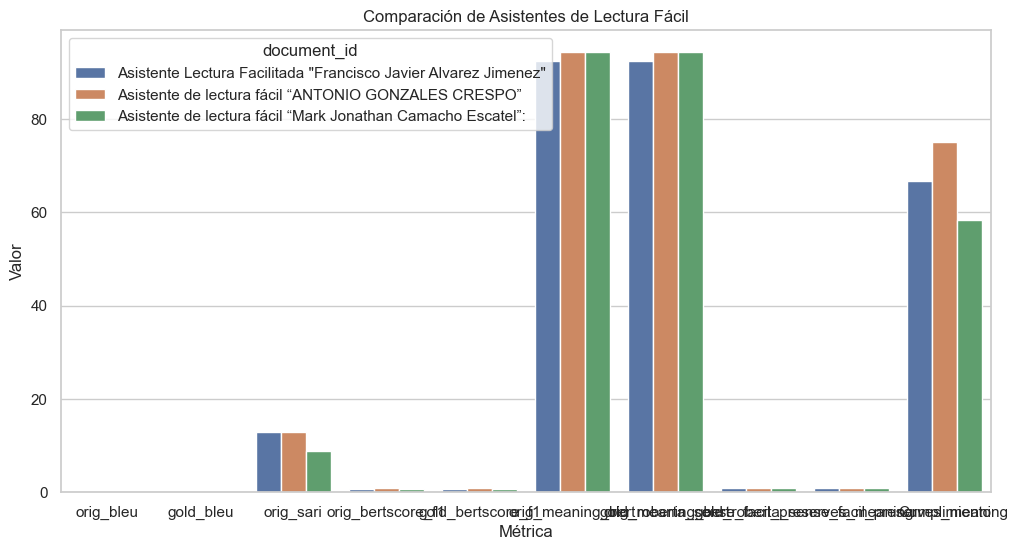

El mejor asistente es: Asistente de lectura fácil “ANTONIO GONZALES CRESPO”


In [23]:
df_asist = df[df['document_id'].str.contains('Asistente')].copy()
display(df_asist[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

# Gráfica comparativa
df_asist_melt = df_asist.melt(id_vars='document_id', value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_asist_melt, x='Métrica', y='Valor', hue='document_id')
plt.title('Comparación de Asistentes de Lectura Fácil')
plt.show()

mejor_asist_id = df_asist.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print("El mejor asistente es:", mejor_asist_id)


## 3. Análisis de Modelos: Modelos Base
Comparación entre modelos puros (Claude, GPT, Gemini, Deepseek) y Placea.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
8,Placea,0.1875,0.1875,15.9843,0.7998,0.7998,94.5086,94.5086,0.9718,0.9718,75.0
10,deepseek-v3.2,0.1578,0.1578,15.0683,0.7756,0.7756,88.5189,88.5189,0.9792,0.9792,75.0
5,GPT 5.4 Think,0.0975,0.0975,13.5932,0.7542,0.7542,90.5149,90.5149,0.9900,0.9900,75.0
6,Gemini 3.1 Pro,0.0817,0.0817,12.4833,0.7302,0.7302,92.2728,92.2728,0.9911,0.9911,75.0
3,Claude Sonnet 4.6,0.0749,0.0749,10.2905,0.7492,0.7492,91.3480,91.3480,0.9678,0.9678,75.0


C:\Users\prestamo_admin\AppData\Local\Temp\ipykernel_25820\3089177962.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_base, x='document_id', y=SummaryColumn.ORIG_SARI, palette='viridis')


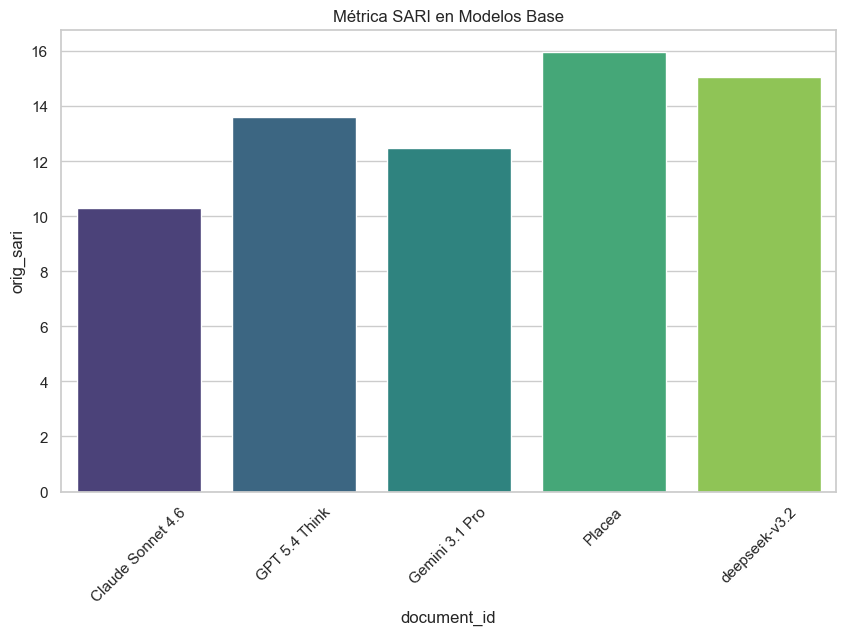

El mejor modelo base es: Placea


In [24]:
modelos_base_nombres = ['Claude Sonnet 4.6', 'GPT 5.4 Think', 'Gemini 3.1 Pro', 'deepseek-v3.2', 'Placea']
df_base = df[df['document_id'].isin(modelos_base_nombres)].copy()
display(df_base[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

# Gráfica comparativa SARI
plt.figure(figsize=(10, 6))
sns.barplot(data=df_base, x='document_id', y=SummaryColumn.ORIG_SARI, palette='viridis')
plt.title('Métrica SARI en Modelos Base')
plt.xticks(rotation=45)
plt.show()

mejor_base_id = df_base.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print("El mejor modelo base es:", mejor_base_id)


## 4. Comparación de los Mejores Modelos de IA
Comparamos a los ganadores de cada categoría anterior.

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
8,Placea,0.1875,0.1875,15.9843,0.7998,0.7998,94.5086,94.5086,0.9718,0.9718,75.0
1,Asistente de lectura fácil “ANTONIO GONZALES C...,0.1296,0.1296,12.9829,0.7804,0.7804,94.3817,94.3817,0.9839,0.9839,75.0


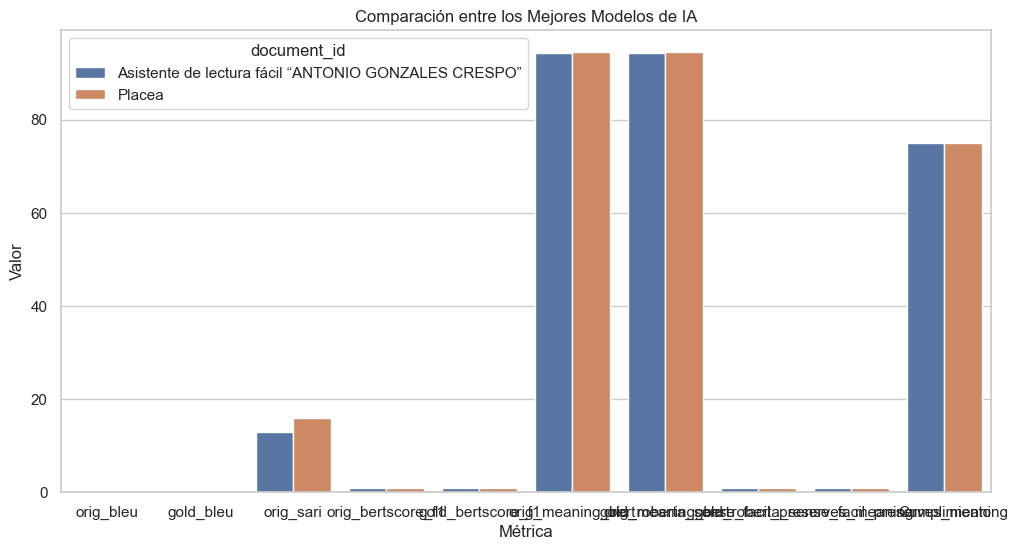

El Mejor Modelo Global de IA es: Placea


In [25]:
mejores_modelos_ids = [mejor_asist_id, mejor_base_id]
df_mejores_modelos = df[df['document_id'].isin(mejores_modelos_ids)].copy()
display(df_mejores_modelos[['document_id'] + metricas].sort_values(by=ORDER_BY, ascending=False))

df_mejores_melt = df_mejores_modelos.melt(id_vars='document_id', value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_mejores_melt, x='Métrica', y='Valor', hue='document_id')
plt.title('Comparación entre los Mejores Modelos de IA')
plt.show()

el_mejor_modelo_id = df_mejores_modelos.sort_values(by=ORDER_BY, ascending=False).iloc[0]['document_id']
print("El Mejor Modelo Global de IA es:", el_mejor_modelo_id)


## 5. Comparación Final: Normas UNE vs El Mejor Modelo de IA
Finalmente, comparamos el mejor enfoque basado en LLMs frente a las herramientas tradicionales basadas en normas UNE (FACILE y SimpleText).

,document_id,Grupo,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
9,SimpleText (ClearText),Normas UNE,0.8904,0.8904,31.8754,0.9871,0.9871,94.5269,94.5269,0.9285,0.9285,66.667
4,FACILE,Normas UNE,0.8953,0.8953,31.8420,0.9816,0.9816,94.5269,94.5269,0.9503,0.9503,75.000
8,Placea,Modelos IA,0.1875,0.1875,15.9843,0.7998,0.7998,94.5086,94.5086,0.9718,0.9718,75.000


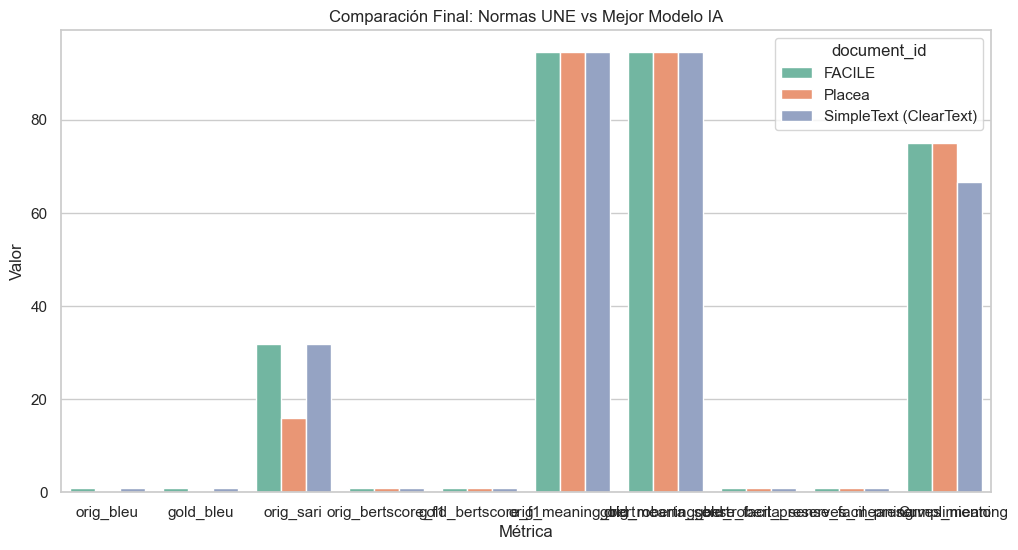

In [26]:
df_final = df[df['document_id'].isin([el_mejor_modelo_id] + une_tools)].copy()
display(df_final[['document_id', 'Grupo'] + metricas].sort_values(by=ORDER_BY, ascending=False))

df_final_melt = df_final.melt(id_vars=['document_id', 'Grupo'], value_vars=metricas, var_name='Métrica', value_name='Valor')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_final_melt, x='Métrica', y='Valor', hue='document_id', palette='Set2')
plt.title('Comparación Final: Normas UNE vs Mejor Modelo IA')
plt.show()


## 6. Análisis de Estabilidad y Relación con SARI
En esta sección analizamos qué tan "estables" son las herramientas. La estabilidad se define como la consistencia en el rendimiento a través de todas las métricas. 
Para esto:
1. Normalizamos todas las métricas (escala 0-1).
2. Calculamos la desviación estándar de estas métricas para cada herramienta. Una desviación baja indica mayor estabilidad (equilibrio entre calidad de simplificación, preservación semántica y legibilidad).

Herramientas ordenadas por Estabilidad (Menor Desviación Estándar = Más Estable)


,document_id,orig_sari,estabilidad_std,promedio_norm
4,FACILE,31.8420,0.272742,0.865508
3,Claude Sonnet 4.6,10.2905,0.330293,0.359562
0,"Asistente Lectura Facilitada ""Francisco Javier...",12.9024,0.335037,0.462005
8,Placea,15.9843,0.349709,0.565597
10,deepseek-v3.2,15.0683,0.368324,0.361281
5,GPT 5.4 Think,13.5932,0.399027,0.426047
1,Asistente de lectura fácil “ANTONIO GONZALES C...,12.9829,0.410764,0.559248
9,SimpleText (ClearText),31.8754,0.415143,0.773844
7,Modelo_Qwen3.5_9B,10.0435,0.427682,0.395144
6,Gemini 3.1 Pro,12.4833,0.432403,0.462100


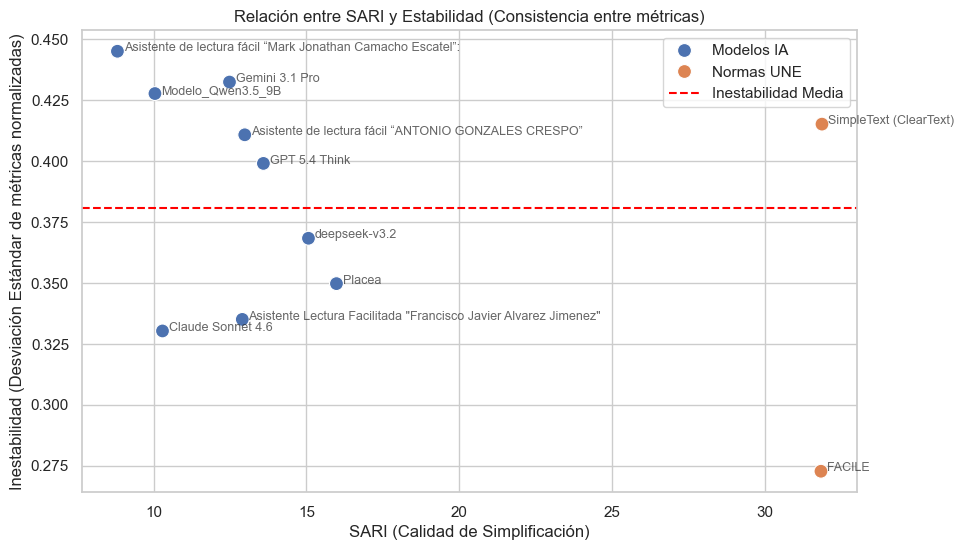

Correlación entre SARI e Inestabilidad: -0.41


In [27]:
# Normalización de métricas
df_m = df[['document_id'] + metricas].set_index('document_id')
df_norm = (df_m - df_m.min()) / (df_m.max() - df_m.min())

# Calcular Estabilidad (desviación estándar de métricas normalizadas)
# Menor desviación = Mayor estabilidad/equilibrio entre métricas
df['estabilidad_std'] = df_norm.std(axis=1).values
df['promedio_norm'] = df_norm.mean(axis=1).values

# Mostrar tabla de estabilidad
print("Herramientas ordenadas por Estabilidad (Menor Desviación Estándar = Más Estable)")
display(df[['document_id', SummaryColumn.ORIG_SARI, 'estabilidad_std', 'promedio_norm']].sort_values(by='estabilidad_std'))

# Gráfica de dispersión: SARI vs Estabilidad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=SummaryColumn.ORIG_SARI, y='estabilidad_std', hue='Grupo', s=100)
for i in range(df.shape[0]):
    plt.text(df[SummaryColumn.ORIG_SARI].iloc[i]+0.2, df.estabilidad_std.iloc[i], df.document_id.iloc[i], fontsize=9, alpha=0.7)

plt.title('Relación entre SARI y Estabilidad (Consistencia entre métricas)')
plt.xlabel('SARI (Calidad de Simplificación)')
plt.ylabel('Inestabilidad (Desviación Estándar de métricas normalizadas)')
plt.axhline(df['estabilidad_std'].mean(), color='red', linestyle='--', label='Inestabilidad Media')
plt.legend()
plt.show()

# Correlación de Pearson
corr = df[[SummaryColumn.ORIG_SARI, 'estabilidad_std']].corr().iloc[0,1]
print(f"Correlación entre SARI e Inestabilidad: {corr:.2f}")


## Store all data of the metrics calculate

In [28]:
df.to_excel('analisis_herramientas_completo.xlsx', index=False)

# Get Metrics of Gold Reference

In [30]:
df_golf = pd.read_excel("comparacion_capa2.xlsx", sheet_name='Matriz comparativa')

In [31]:
ORIGINAL_FORM = ""
REFERENCE_FORM = ""

for row in df_golf.itertuples():
    if row[2] == "TEXTO ADAPTADO (SALIDA DE CADA HERRAMIENTA DE LF)":
        ORIGINAL_FORM = clean_text(row[3])
        REFERENCE_FORM = clean_text(row[4])

print("Texto Original:", ORIGINAL_FORM[:150])
print("="*50)
print("Texto de Referencia:", REFERENCE_FORM[:150])

Texto Original: Información sobre protección de datos Este cuestionario ha sido diseñado de forma que se preserve totalmente su carácter anónimo. No obstante, conside
Texto de Referencia: Información sobre protección de datos. Se ha diseñado este cuestionario de forma que se preserve del todo su carácter anónimo. Consideramos oportuno i


In [32]:
cal = MerTrans()
bleu=cal.get_bleu_metric([ORIGINAL_FORM], [REFERENCE_FORM])
bertscore=cal.get_bert_score([ORIGINAL_FORM], [REFERENCE_FORM])
meaning_bert=cal.get_meaning_bert_score([ORIGINAL_FORM], [REFERENCE_FORM])
roberta_sense_facil=cal.get_roberta_sense_facil_metric([ORIGINAL_FORM], [REFERENCE_FORM])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2487.37it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3183.42it/s]


In [33]:
metrics_min =df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].min()

metrics_max = df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].max()

metrics_mean = df[[
    SummaryColumn.ORIG_BLEU, 
    SummaryColumn.ORIG_BERTSCORE_F1, 
    SummaryColumn.ORIG_MEANING_BERT,
    SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING
    ]].mean()

In [34]:
df_metrics_gold_summary = pd.DataFrame(
    {
        "Métrica": ["BLEU", "BERTScore F1", "Meaning BERT", "Roberta Sense Facil"],
        "Valor": [bleu.bleu, bertscore.mean_f1, meaning_bert.mean_score, roberta_sense_facil.preserves_meaning],
        "Min": [metrics_min[SummaryColumn.ORIG_BLEU], metrics_min[SummaryColumn.ORIG_BERTSCORE_F1], metrics_min[SummaryColumn.ORIG_MEANING_BERT], metrics_min[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]],
        "Max": [metrics_max[SummaryColumn.ORIG_BLEU], metrics_max[SummaryColumn.ORIG_BERTSCORE_F1], metrics_max[SummaryColumn.ORIG_MEANING_BERT], metrics_max[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]],
        "Mean": [metrics_mean[SummaryColumn.ORIG_BLEU], metrics_mean[SummaryColumn.ORIG_BERTSCORE_F1], metrics_mean[SummaryColumn.ORIG_MEANING_BERT], metrics_mean[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING]]
    }

)

In [35]:
df_metrics_gold_summary

,Métrica,Valor,Min,Max,Mean
0,BLEU,0.895344,0.0484,0.8953,0.253864
1,BERTScore F1,0.981553,0.7118,0.9871,0.800718
2,Meaning BERT,94.526878,88.5189,94.5269,92.904836
3,Roberta Sense Facil,0.950306,0.9285,0.9911,0.973173


In [36]:
print(bleu.bleu)
print(bertscore.mean_f1)
print(meaning_bert.mean_score)
print(roberta_sense_facil.preserves_meaning)

0.8953437733111483
0.981553316116333
94.5268783569336
0.9503055214881897


In [37]:
bertscore

BertScoreMetric(precision=[0.9809960126876831], recall=[0.9821112155914307], f1=[0.981553316116333], mean_precision=0.9809960126876831, mean_recall=0.9821112155914307, mean_f1=0.981553316116333)

In [38]:
df[df[SummaryColumn.ORIG_BLEU] >= bleu.bleu][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_BLEU, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento


In [39]:
df[df[SummaryColumn.ORIG_BERTSCORE_F1] >= bertscore.mean_f1][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_BERTSCORE_F1, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
9,SimpleText (ClearText),0.8904,0.8904,31.8754,0.9871,0.9871,94.5269,94.5269,0.9285,0.9285,66.667
4,FACILE,0.8953,0.8953,31.8420,0.9816,0.9816,94.5269,94.5269,0.9503,0.9503,75.000


In [40]:
df[df[SummaryColumn.ORIG_MEANING_BERT] >= meaning_bert.mean_score][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_MEANING_BERT, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
4,FACILE,0.8953,0.8953,31.8420,0.9816,0.9816,94.5269,94.5269,0.9503,0.9503,75.000
9,SimpleText (ClearText),0.8904,0.8904,31.8754,0.9871,0.9871,94.5269,94.5269,0.9285,0.9285,66.667


In [41]:
df[df[SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING] >= roberta_sense_facil.preserves_meaning][["document_id"] + metricas].sort_values(by=SummaryColumn.ORIG_ROBERTA_SENSE_FACIL_PRESERVES_MEANING, ascending=False)

,document_id,orig_bleu,gold_bleu,orig_sari,orig_bertscore_f1,gold_bertscore_f1,orig_meaning_bert,gold_meaning_bert,orig_roberta_sense_facil_preserves_meaning,gold_roberta_sense_facil_preserves_meaning,Cumplimiento
6,Gemini 3.1 Pro,0.0817,0.0817,12.4833,0.7302,0.7302,92.2728,92.2728,0.9911,0.9911,75.000
5,GPT 5.4 Think,0.0975,0.0975,13.5932,0.7542,0.7542,90.5149,90.5149,0.9900,0.9900,75.000
0,"Asistente Lectura Facilitada ""Francisco Javier...",0.1193,0.1193,12.9024,0.7715,0.7715,92.4701,92.4701,0.9841,0.9841,66.667
1,Asistente de lectura fácil “ANTONIO GONZALES C...,0.1296,0.1296,12.9829,0.7804,0.7804,94.3817,94.3817,0.9839,0.9839,75.000
2,Asistente de lectura fácil “Mark Jonathan Cama...,0.1101,0.1101,8.8155,0.7118,0.7118,94.3599,94.3599,0.9827,0.9827,58.333
10,deepseek-v3.2,0.1578,0.1578,15.0683,0.7756,0.7756,88.5189,88.5189,0.9792,0.9792,75.000
7,Modelo_Qwen3.5_9B,0.0484,0.0484,10.0435,0.7665,0.7665,94.5245,94.5245,0.9755,0.9755,41.667
8,Placea,0.1875,0.1875,15.9843,0.7998,0.7998,94.5086,94.5086,0.9718,0.9718,75.000
3,Claude Sonnet 4.6,0.0749,0.0749,10.2905,0.7492,0.7492,91.3480,91.3480,0.9678,0.9678,75.000
